## Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Blues_r')

##  Load the dataset

In [2]:
df = pd.read_csv(r"C:\Users\mohamed farhan\OneDrive\Documents\BIA intern project\intern project 4\mumbai-monthly-rains.csv")


## Understand the dataset

In [3]:
df.head()

,Year,Jan,Feb,Mar,April,May,June,July,Aug,Sept,Oct,Nov,Dec,Total
0,1901,13.116602,0.000000,0.000000,3.949669,17.139791,640.714036,888.369692,545.045796,64.271513,9.871696,0.000000,0.000000,2182.478796
1,1902,0.000000,0.000000,0.000000,0.000000,0.355001,247.998782,408.433730,566.595863,688.913455,28.654092,0.488864,19.526547,1960.966334
2,1903,0.000000,0.000000,0.844034,0.000000,220.568740,370.849048,902.447896,602.420828,264.589816,157.892877,0.000000,0.000000,2519.613240
3,1904,0.000000,0.000000,11.381769,0.000000,0.000000,723.081969,390.886799,191.581927,85.704754,38.679948,0.000000,0.000000,1441.317168
4,1905,0.662561,1.713452,0.000000,0.000000,0.000000,123.870892,581.827975,167.382149,172.297723,7.365924,24.903575,0.000000,1080.024250


In [5]:
df.shape

(121, 14)

In [9]:
df.isnull().sum()

Year     0
Jan      0
Feb      0
Mar      0
April    0
May      0
June     0
July     0
Aug      0
Sept     0
Oct      0
Nov      0
Dec      0
Total    0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

## Convert wide data into monthly time series

In [11]:
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'Aug': 8, 'Sept': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}

df_long = df.melt(
    id_vars=['Year', 'Total'],
    value_vars=list(month_map.keys()),
    var_name='Month',
    value_name='Rainfall'
)

df_long['Month_Num'] = df_long['Month'].map(month_map)
df_long = df_long.sort_values(['Year', 'Month_Num']).reset_index(drop=True)

df_long['Date'] = pd.to_datetime(
    df_long['Year'].astype(str) + '-' + df_long['Month_Num'].astype(str) + '-01'
)

df_long = df_long[['Date', 'Year', 'Month', 'Month_Num', 'Rainfall']]

df_long.head(15)

,Date,Year,Month,Month_Num,Rainfall
0,1901-01-01,1901,Jan,1,13.116602
1,1901-02-01,1901,Feb,2,0.000000
2,1901-03-01,1901,Mar,3,0.000000
3,1901-04-01,1901,April,4,3.949669
4,1901-05-01,1901,May,5,17.139791
5,1901-06-01,1901,June,6,640.714036
6,1901-07-01,1901,July,7,888.369692
7,1901-08-01,1901,Aug,8,545.045796
8,1901-09-01,1901,Sept,9,64.271513
9,1901-10-01,1901,Oct,10,9.871696


##  Check transformed data

In [12]:
print("Monthly dataset shape:", df_long.shape)
df_long.info()
df_long.describe()

Monthly dataset shape: (1452, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1452 entries, 0 to 1451
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1452 non-null   datetime64[ns]
 1   Year       1452 non-null   int64         
 2   Month      1452 non-null   object        
 3   Month_Num  1452 non-null   int64         
 4   Rainfall   1452 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(2), object(1)
memory usage: 56.8+ KB


,Date,Year,Month_Num,Rainfall
count,1452,1452.000000,1452.000000,1452.000000
mean,1961-06-16 08:01:59.008264448,1961.000000,6.500000,180.676309
min,1901-01-01 00:00:00,1901.000000,1.000000,0.000000
25%,1931-03-24 06:00:00,1931.000000,3.750000,0.000000
50%,1961-06-16 00:00:00,1961.000000,6.500000,3.013463
75%,1991-09-08 12:00:00,1991.000000,9.250000,285.018462
max,2021-12-01 00:00:00,2021.000000,12.000000,1358.833554
std,NaN,34.940532,3.453242,293.125556


## Plot monthly rainfall trend

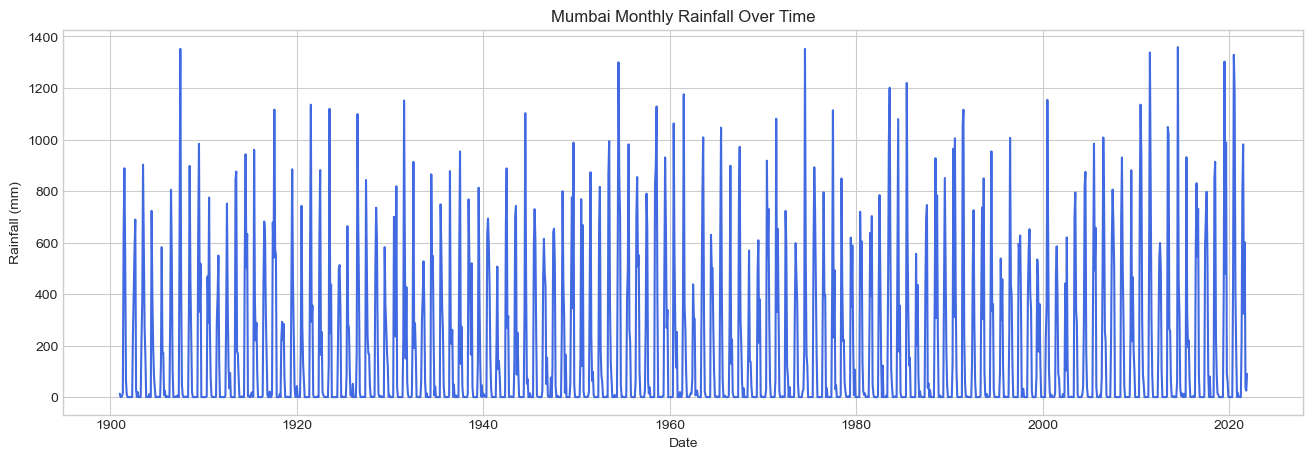

In [13]:
plt.figure(figsize=(16, 5))
plt.plot(df_long['Date'], df_long['Rainfall'], color='royalblue')
plt.title('Mumbai Monthly Rainfall Over Time')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.show()

## Average rainfall by month

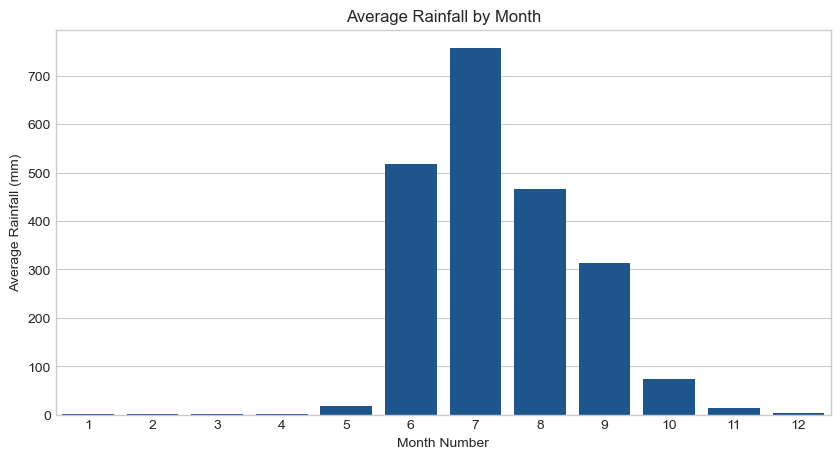

,Month_Num,Rainfall
0,1,1.567235
1,2,0.929358
2,3,0.869231
3,4,1.428458
4,5,18.183632
5,6,517.854402
6,7,757.407412
7,8,465.600818
8,9,312.885747
9,10,73.983526


In [14]:
monthly_avg = df_long.groupby('Month_Num')['Rainfall'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_avg, x='Month_Num', y='Rainfall')
plt.title('Average Rainfall by Month')
plt.xlabel('Month Number')
plt.ylabel('Average Rainfall (mm)')
plt.show()

monthly_avg

## Annual rainfall trend

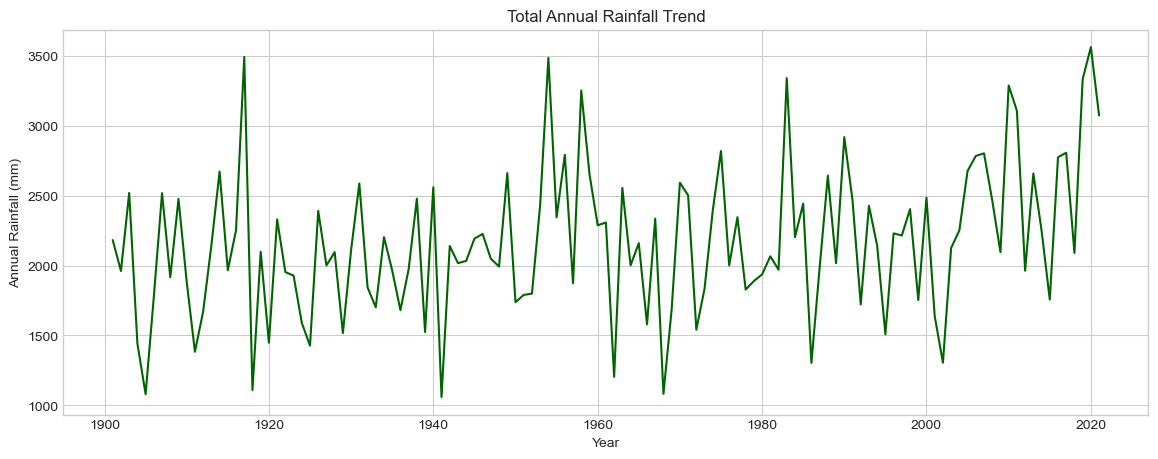

,Year,Annual_Rainfall
0,1901,2182.478796
1,1902,1960.966334
2,1903,2519.613240
3,1904,1441.317168
4,1905,1080.024250


In [15]:
yearly_rain = df_long.groupby('Year')['Rainfall'].sum().reset_index(name='Annual_Rainfall')

plt.figure(figsize=(14, 5))
sns.lineplot(data=yearly_rain, x='Year', y='Annual_Rainfall', color='darkgreen')
plt.title('Total Annual Rainfall Trend')
plt.xlabel('Year')
plt.ylabel('Annual Rainfall (mm)')
plt.show()

yearly_rain.head()

## Heatmap of rainfall

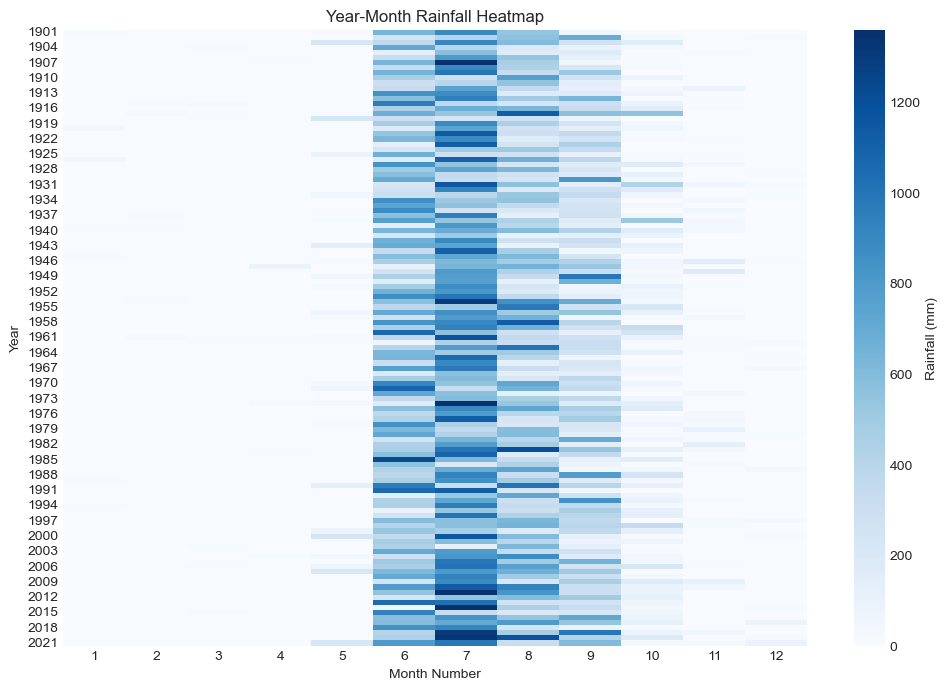

In [16]:
pivot_month = df_long.pivot_table(index='Year', columns='Month_Num', values='Rainfall')

plt.figure(figsize=(12, 8))
sns.heatmap(pivot_month, cmap='Blues', cbar_kws={'label': 'Rainfall (mm)'})
plt.title('Year-Month Rainfall Heatmap')
plt.xlabel('Month Number')
plt.ylabel('Year')
plt.show()

## Create forecasting features

In [17]:
data = df_long.copy()

data['lag_1'] = data['Rainfall'].shift(1)
data['lag_2'] = data['Rainfall'].shift(2)
data['lag_3'] = data['Rainfall'].shift(3)
data['lag_6'] = data['Rainfall'].shift(6)
data['lag_12'] = data['Rainfall'].shift(12)

data['rolling_3'] = data['Rainfall'].shift(1).rolling(3).mean()
data['rolling_6'] = data['Rainfall'].shift(1).rolling(6).mean()

data['year_trend'] = np.arange(len(data))

data = data.dropna().reset_index(drop=True)

data.head()

,Date,Year,Month,Month_Num,Rainfall,lag_1,lag_2,lag_3,lag_6,lag_12,rolling_3,rolling_6,year_trend
0,1902-01-01,1902,Jan,1,0.000000,0.0,0.0,9.871696,888.369692,13.116602,3.290565,251.259783,12
1,1902-02-01,1902,Feb,2,0.000000,0.0,0.0,0.000000,545.045796,0.000000,0.000000,103.198168,13
2,1902-03-01,1902,Mar,3,0.000000,0.0,0.0,0.000000,64.271513,0.000000,0.000000,12.357202,14
3,1902-04-01,1902,April,4,0.000000,0.0,0.0,0.000000,9.871696,3.949669,0.000000,1.645283,15
4,1902-05-01,1902,May,5,0.355001,0.0,0.0,0.000000,0.000000,17.139791,0.000000,0.000000,16


## Select features and target

In [18]:
features = [
    'Month_Num', 'lag_1', 'lag_2', 'lag_3',
    'lag_6', 'lag_12', 'rolling_3', 'rolling_6', 'year_trend'
]

target = 'Rainfall'

X = data[features]
y = data[target]

## Split train and test data

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1152, 9)
X_test shape: (288, 9)
y_train shape: (1152,)
y_test shape: (288,)


## Train Linear Regression

In [24]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

lr_mae = mean_absolute_error(y_test, lr_preds)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression Results")
print("MAE :", lr_mae)
print("RMSE:", lr_rmse)
print("R2  :", lr_r2)

Linear Regression Results
MAE : 125.1827915840729
RMSE: 200.3210242974269
R2  : 0.6196904891692179


## Train Random Forest

In [21]:
rf_model = RandomForestRegressor(n_estimators=300, random_state=42)
rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE:", rf_rmse)
print("R2  :", rf_r2)

Random Forest Results
MAE : 102.37712253788754
RMSE: 181.78983053764998
R2  : 0.6867988906629332


## Compare model performance

In [22]:
results_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [lr_mae, rf_mae],
    'RMSE': [lr_rmse, rf_rmse],
    'R2': [lr_r2, rf_r2]
})

results_df.sort_values(by='RMSE')

,Model,MAE,RMSE,R2
1,Random Forest,102.377123,181.789831,0.686799
0,Linear Regression,125.182792,200.321024,0.619690


## Choose best mode

In [25]:
if rf_rmse < lr_rmse:
    best_model = rf_model
    best_preds = rf_preds
    best_model_name = "Random Forest"
else:
    best_model = lr_model
    best_preds = lr_preds
    best_model_name = "Linear Regression"

print("Best Model:", best_model_name)

Best Model: Random Forest


## Plot actual vs predicted rainfall


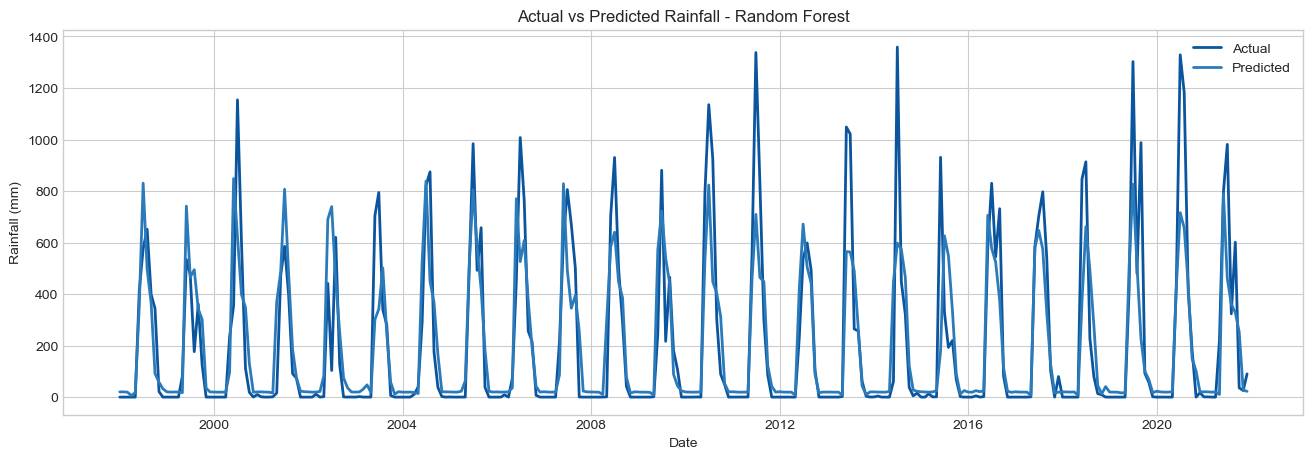

In [26]:
test_dates = data.iloc[len(X_train):]['Date'].reset_index(drop=True)

plt.figure(figsize=(16, 5))
plt.plot(test_dates, y_test.reset_index(drop=True), label='Actual', linewidth=2)
plt.plot(test_dates, best_preds, label='Predicted', linewidth=2)
plt.title(f'Actual vs Predicted Rainfall - {best_model_name}')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

## Forecast next 12 months

In [27]:
forecast_df = data[['Date', 'Year', 'Month_Num', 'Rainfall', 'year_trend']].copy()

future_predictions = []
future_dates = []

for step in range(12):
    last_date = forecast_df.iloc[-1]['Date']
    next_date = last_date + pd.DateOffset(months=1)
    next_month = next_date.month
    next_trend = forecast_df.iloc[-1]['year_trend'] + 1

    lag_1 = forecast_df.iloc[-1]['Rainfall']
    lag_2 = forecast_df.iloc[-2]['Rainfall']
    lag_3 = forecast_df.iloc[-3]['Rainfall']
    lag_6 = forecast_df.iloc[-6]['Rainfall']
    lag_12 = forecast_df.iloc[-12]['Rainfall']

    rolling_3 = forecast_df.iloc[-3:]['Rainfall'].mean()
    rolling_6 = forecast_df.iloc[-6:]['Rainfall'].mean()

    future_row = pd.DataFrame({
        'Month_Num': [next_month],
        'lag_1': [lag_1],
        'lag_2': [lag_2],
        'lag_3': [lag_3],
        'lag_6': [lag_6],
        'lag_12': [lag_12],
        'rolling_3': [rolling_3],
        'rolling_6': [rolling_6],
        'year_trend': [next_trend]
    })

    future_pred = best_model.predict(future_row)[0]
    future_pred = max(0, future_pred)

    future_predictions.append(future_pred)
    future_dates.append(next_date)

    new_row = pd.DataFrame({
        'Date': [next_date],
        'Year': [next_date.year],
        'Month_Num': [next_month],
        'Rainfall': [future_pred],
        'year_trend': [next_trend]
    })

    forecast_df = pd.concat([forecast_df, new_row], ignore_index=True)

future_forecast = pd.DataFrame({
    'Date': future_dates,
    'Forecasted_Rainfall': future_predictions
})

future_forecast

,Date,Forecasted_Rainfall
0,2022-01-01,21.688628
1,2022-02-01,20.072546
2,2022-03-01,20.201630
3,2022-04-01,23.653388
4,2022-05-01,445.296964
5,2022-06-01,864.122227
6,2022-07-01,772.906681
7,2022-08-01,449.119219
8,2022-09-01,391.496632
9,2022-10-01,184.241296


## Plot forecast for next 12 months

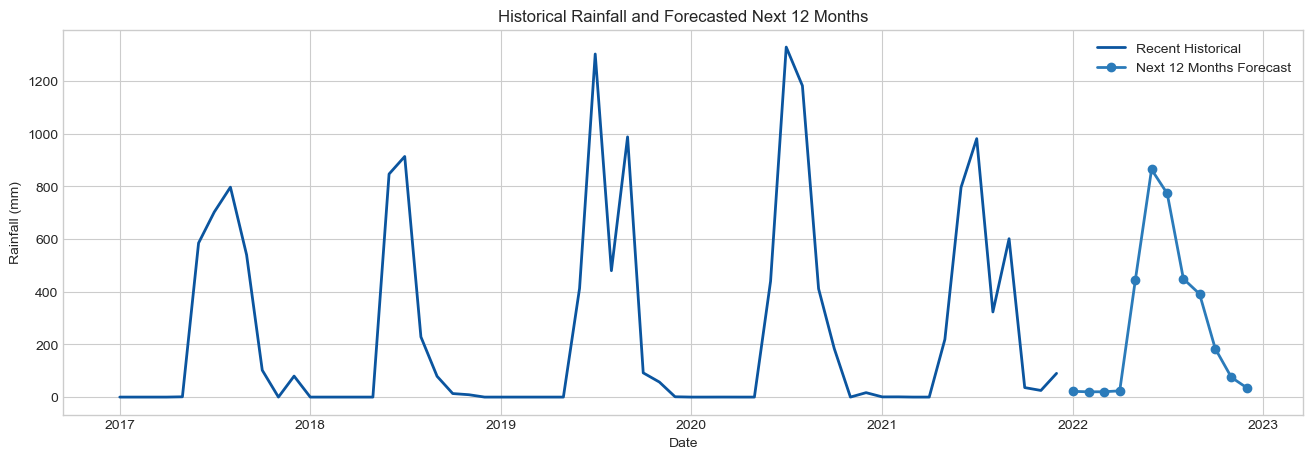

In [28]:
plt.figure(figsize=(16, 5))
plt.plot(df_long['Date'].tail(60), df_long['Rainfall'].tail(60), label='Recent Historical', linewidth=2)
plt.plot(future_forecast['Date'], future_forecast['Forecasted_Rainfall'], label='Next 12 Months Forecast', linewidth=2, marker='o')
plt.title('Historical Rainfall and Forecasted Next 12 Months')
plt.xlabel('Date')
plt.ylabel('Rainfall (mm)')
plt.legend()
plt.show()

##  Save forecast output

In [29]:
future_forecast.to_csv('mumbai_12_month_rainfall_forecast.csv', index=False)
print("Forecast file saved successfully.")


Forecast file saved successfully.
